<a href="https://colab.research.google.com/github/plopezmp/AmI/blob/main/c2021_NoSupervisado_KMeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Preambulo:** 

Montamos nuestro `Google Drive` donde tenemos guardado el notebook de Python.

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
import os
os.chdir('/content/drive/My Drive/Colab Notebooks/')
%pwd

'/content/drive/My Drive/Colab Notebooks'

---

1. [Introducción a K-Means](#sec_kmeans)
2. [Algoritmo: ](#sec_em)
3. [Aplicación de K-Means a `dataset.digits`](#sec_kdigits)



---

Parte de este notebook está recogido del libro: 
- VanderPlas, Jake. *Python data science handbook: Essential tools for working with data.* " O'Reilly Media, Inc.", 2016.

***

Aquí exploraremos **K-Means Clustering**, que es una técnica de clustering *no supervisada*.

Comenzaremos con la importación de librerías comunes.

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.style.use('seaborn')

<a id='sec_kmeans'></a>
# Introducción a K-Means

K-Means es un algoritmo de **clustering** no supervisado: es decir, encontrar clústers en los datos basándose únicamente en los atributos de los datos (**no en las etiquetas**).

K-Means es un algoritmo relativamente fácil de entender. Busca **centros** de agrupamientos, que representan una posición *media* dentro del agrupamiento. 

Cada punto tendrá asignado un *centro*, y será el más cercano.

Veamos cómo funciona K-Means un ejemplo de clusters. 
No trazaremos los colores de los diferentes grupos Para remarcar el carácter no supervisado del algoritmo:

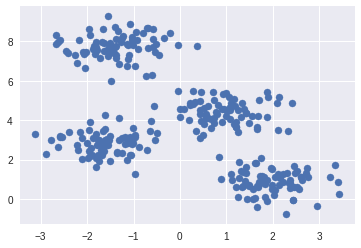

In [ ]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=300, centers=4,
                  random_state=0, cluster_std=0.60)
plt.scatter(X[:, 0], X[:, 1], s=50);

A ojo se pueden identificar 4 gupos de datos. 
Sin embargo, en un espacio >2D resolver la agrupación de puntos resulta muy complicada.

Afortunadamente, existe un conocido procedimiento *Expectation Maximization (EM)* que `scikit-learn` implementa, de modo que los K-Means se pueden resolver con relativa rapidez.

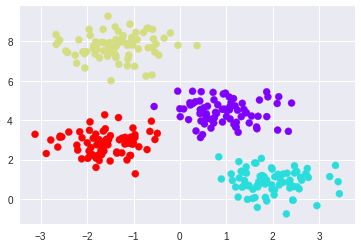

In [ ]:
from sklearn.cluster import KMeans
est = KMeans(4)  # 4 clusters
est.fit(X)
y_kmeans = est.predict(X)
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='rainbow');

El algoritmo identifica los puntos de forma similiar a como haría una persona que viera la representación.

<a id='sec_em'></a>
# Algoritmo: 

K-Means es un ejemplo de un algoritmo que utiliza un enfoque de *Expectation Maximizacion* para llegar a la solución.
Es un enfoque de dos pasos que funciona de la siguiente manera:

1. Adivina algunos centros de cluster
2. Repitir hasta que converja (no haya variación de la posición de los centros de cluster):
    1. **Cluster assignament step:** recorre todos los puntos y les asigna un *centroide*. Para ello, cada punto ve su distancia a uno de los centroides y se etiqueta con el que esté más cerca.
    2. **Move centroid step:** calcula el valor medio o el `mean` value de los puntos del cluster y *mueve* el centroide a ese punto.
  
   
Visualicemos este proceso:

In [ ]:
"""
NOTA: Para cargar la función "plot_kmeans_interactive()" 
debéis copiar el paquete de Python "fig_code" (directorio)
donde ejecutéis el notebook o en alguna localización del PYTHONPATH
"""

from fig_code import plot_kmeans_interactive
plot_kmeans_interactive(1,4); # (min, max) número de centros

interactive(children=(IntSlider(value=0, description='frame', max=50), Dropdown(description='n_clusters', inde…

**Ventajas:**

- El algoritmo sencillo y se entiende bien.

- Sirve para entender otros métodos de *clustering*.

**Inconvenientes:**

- La convergencia de K-Means no está garantizada. Por esta razón `scikit-learn` repite el proceso varias veces iniciando con centros en posiciones aleatorias. El algoritmo finalmente se queda con el mejor resultado. 

- Además, el número de clusters debemos fijarlo de antemano.

- Funciona regular con clusters *elongados* o estirados.

- Padece la denominada *maldición de la dimensionalidad* que consiste en que las distancias Euclídeas tienden a ser grandes cuando el número de dimensione es grande. En estos casos, se puede reducir la dimensión aplicando `Principal Component Analysis (PCA)` antes de `K-means`.


## Reto: Algoritmo K-means

Aprovechando el código que tenemos hecho para generar *grupos* de puntos dato, implemente el algoritmo `K-means`, es decir, no puede usar funciones de `scikit-learn`. Ponga comentarios en el código.

<a id='sec_kdigits'></a>
# Aplicación de K-Means a `dataset.digits`

Para ver un ejemplo de aplicación real, volvamos a echar un vistazo a los datos de los dígitos. Aquí usaremos K-Means para agrupar automáticamente los datos en 64 dimensiones, y luego observaremos los centros de los clusters para ver qué ha encontrado el algoritmo.

In [ ]:
from sklearn.datasets import load_digits
digits = load_digits()

In [ ]:
est = KMeans(n_clusters=10)
clusters = est.fit_predict(digits.data)
est.cluster_centers_.shape

(10, 64)

Observamos 10 clasters de 64-dim. 

Veamos los centros de dichos clasters para ver qué representan:

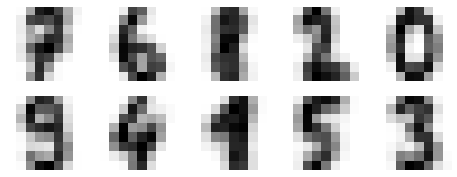

In [ ]:
fig = plt.figure(figsize=(8, 3))
for i in range(10):
    ax = fig.add_subplot(2, 5, 1 + i, xticks=[], yticks=[])
    ax.imshow(est.cluster_centers_[i].reshape((8, 8)), cmap=plt.cm.binary)

El algoritmo ha identificado cada uno de los 10 dígitos (el 8 un poco peor...).

Las etiquetas no están correctamente ubicadas, pero podemos solucionarlo:

In [ ]:
from scipy.stats import mode

labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

Por si acaso, usemos nuestra visualización de PCA y observemos las etiquetas de clúster verdaderas y las etiquetas de clúster de K-mean:

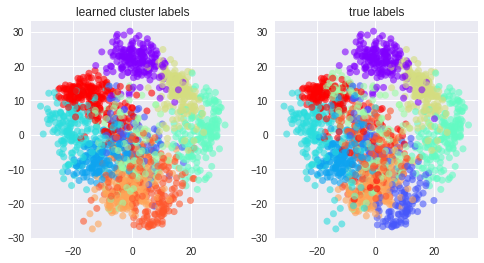

In [ ]:
from sklearn.decomposition import PCA

X = PCA(2).fit_transform(digits.data)

kwargs = dict(cmap = plt.cm.get_cmap('rainbow', 10),
              edgecolor='none', alpha=0.6)
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].scatter(X[:, 0], X[:, 1], c=labels, **kwargs)
ax[0].set_title('learned cluster labels')

ax[1].scatter(X[:, 0], X[:, 1], c=digits.target, **kwargs)
ax[1].set_title('true labels');

Veamos qué tan preciso es nuestro clasificador K-Means sin información de etiqueta:

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(digits.target, labels)

0.7946577629382304

Un $\approx 80\%$ está bastante bien para un **estimador completamente no supervisado** que no sabe nada de las etiquetas de cada imagen de dígito.

Ahora comprobemos la matriz de confusión de nuestro modelo.

[[177   0   0   0   1   0   0   0   0   0]
 [  0  55  24   1   0   1   2   0  99   0]
 [  1   2 148  13   0   0   0   3   8   2]
 [  0   0   1 158   0   2   0   6   7   9]
 [  0   3   0   0 166   0   0   9   3   0]
 [  0   0   0   1   1 137   1   0   0  42]
 [  1   1   0   0   0   0 177   0   2   0]
 [  0   2   0   0   0   5   0 170   2   0]
 [  0   6   3   4   0   6   2   3 102  48]
 [  0  20   0   7   0   6   0   7   2 138]]


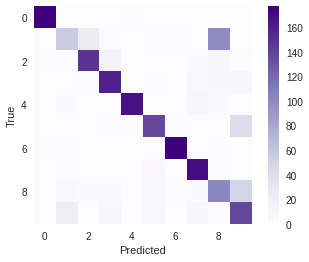

In [ ]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(digits.target, labels))

plt.imshow(confusion_matrix(digits.target, labels),
           cmap='Purples', interpolation='nearest')
plt.colorbar()
plt.grid(False)
plt.ylabel('True')
plt.xlabel('Predicted');

## Referencias útiles



*   Géron, Aurélien. *Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow: Concepts, tools, and techniques to build intelligent systems*. O'Reilly Media, 2019.
*   Scikit-klearn documentation on Clustering. [online: https://scikit-learn.org/stable/modules/clustering.html#mini-batch-kmeans
*  VanderPlas, Jake. *Python data science handbook: Essential tools for working with data.* " O'Reilly Media, Inc.", 2016.



